# Projeto de conversão #

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq


In [ ]:
H_tab = np.array([0,68,135,203,271,338,406,474,542,609,1100,1500,2500,4000,5000,9000,12000,20000,25000]) #A/m
B_tab = np.array([0,0.733,1.205,1.424,1.517,1.560,1.588,1.617,1.631,1.646,1.689,1.703,1.724,1.731,1.738,1.761,1.770,1.800,1.816]) # T

mm = 1e-3
cm = 1e-2

alpha =  60                 # Comprimento angular dos polos do rotor e do estator (°) (alpha = beta)
g = 0.45*mm                 # Comprimento do Entreferro
l = 20*cm                   # Comprimento medio do caminho magnetico no nucleo
R = 6.3*cm                  # Raio do rotor
D = 8*cm                    # Comprimento axial da Maquina
N = 90                      # Numero de Espiras
theta_m_inicial = 0         # Posicao angular do rotor em relacao ao estator (°)
Rb = 0.2                    # Resistencia eletrica total da bobina e do sistema de alimentacao (ohms)
J = 0.010                   # Momento de inercia do rotor (kg * m²)

# constantes

u0 = 4*np.pi * 1e-7         # H/m

#### curva BxH ####

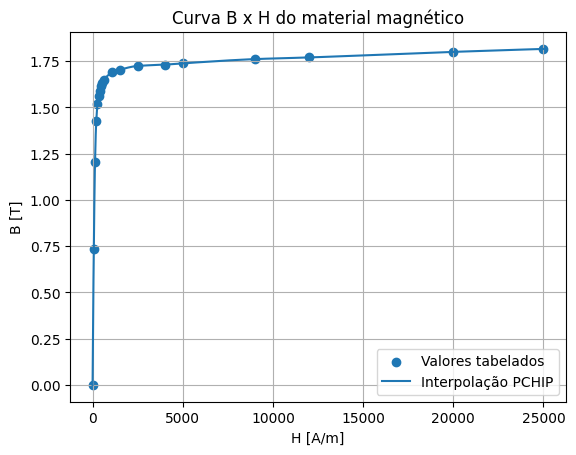

In [ ]:
# Interpolação monotônica da curva B x H e de sua inversa.
# A extrapolação acima do último ponto é feita linearmente
# usando a inclinação do último trecho tabelado.

B_interp = PchipInterpolator(H_tab, B_tab, extrapolate=False)
H_interp = PchipInterpolator(B_tab, H_tab, extrapolate=False)

dB_dH_final = (B_tab[-1] - B_tab[-2]) / (H_tab[-1] - H_tab[-2])
dH_dB_final = 1.0 / dB_dH_final

def B_de_H(H):
    H_arr = np.asarray(H, dtype=float)
    H_clip = np.clip(H_arr, H_tab[0], H_tab[-1])

    B = B_interp(H_clip)
    B = np.where(
        H_arr > H_tab[-1],
        B_tab[-1] + dB_dH_final*(H_arr - H_tab[-1]),
        B
    )
    B = np.where(H_arr < 0, 0.0, B)

    return float(B) if np.ndim(B) == 0 else B

def H_de_B(B):
    B_arr = np.asarray(B, dtype=float)
    B_clip = np.clip(B_arr, B_tab[0], B_tab[-1])

    H = H_interp(B_clip)
    H = np.where(
        B_arr > B_tab[-1],
        H_tab[-1] + dH_dB_final*(B_arr - B_tab[-1]),
        H
    )
    H = np.where(B_arr < 0, 0.0, H)

    return float(H) if np.ndim(H) == 0 else H

H_plot = np.linspace(H_tab[0], H_tab[-1], 1001)
B_plot = B_de_H(H_plot)

plt.scatter(H_tab, B_tab, label='Valores tabelados')
plt.plot(H_plot, B_plot, label='Interpolação PCHIP')
plt.grid(True)
plt.title('Curva B x H do material magnético')
plt.legend(loc='best')
plt.xlabel('H [A/m]')
plt.ylabel('B [T]')
plt.show()


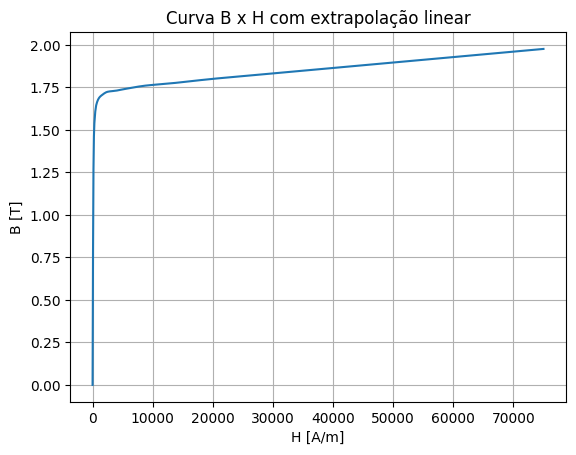

In [ ]:
H_teste = np.linspace(0, 3*H_tab[-1], 1001)
B_teste = B_de_H(H_teste)

plt.plot(H_teste, B_teste)
plt.grid(True)
plt.title('Curva B x H com extrapolação linear')
plt.xlabel('H [A/m]')
plt.ylabel('B [T]')
plt.show()


## Etapa 1 ##

### Questão 1 ###

In [ ]:
A_rotor = np.pi*alpha/180 * R * D

def alpha_sobreposicao(theta):
    """
    Ângulo de sobreposição entre os polos do rotor e do estator.
    Para |theta| >= 60°, a área sobreposta é nula.
    """
    return max(alpha - abs(theta), 0.0)

def Area_entreferro(theta):
    """
    Área efetivamente sobreposta no entreferro.
    """
    alpha_overlap = alpha_sobreposicao(theta)
    return np.pi*alpha_overlap/180 * R * D

def f_H_rotor(H_rotor, I, theta):
    """
    Resíduo da lei de Ampère:
        N I = H_nucleo*l + 2*H_g*g

    A continuidade do fluxo fornece:
        B_g*A_g = B_nucleo*A_rotor
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        return -N*I

    B_rotor = B_de_H(H_rotor)
    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_rotor*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return queda_nucleo + queda_entreferro - N*I

def determina_H_rotor(I, theta):
    """
    Campo magnético no núcleo para uma corrente e posição dadas.
    """
    if I <= 0 or Area_entreferro(theta) <= 0:
        return 0.0

    a = 0.0
    b = H_tab[-1]

    # Expande o limite superior até garantir mudança de sinal.
    while f_H_rotor(b, I, theta) < 0:
        b *= 2.0

    return brentq(
        lambda H: f_H_rotor(H, I, theta),
        a,
        b,
        xtol=1e-10,
        rtol=1e-10
    )

def determina_B_rotor(I, theta):
    """
    Densidade de fluxo magnético no núcleo.
    """
    return B_de_H(determina_H_rotor(I, theta))

def Phi_B(I, theta):
    """
    Fluxo magnético no núcleo.
    """
    if I <= 0 or Area_entreferro(theta) <= 0:
        return 0.0

    return determina_B_rotor(I, theta)*A_rotor

def fluxo_concatenado(I, theta):
    """
    Fluxo concatenado lambda = N*Phi.
    """
    return N*Phi_B(I, theta)


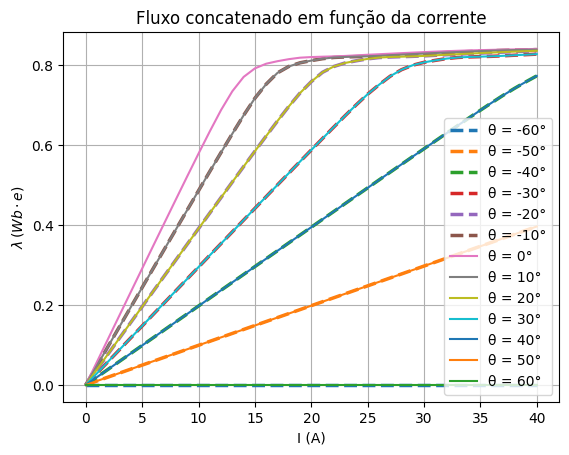

In [ ]:
correntes = np.linspace(0,40,41)
angulos = np.arange(-60, 61, 10)

for angulo in angulos:
    fluxo_concatenado_array = np.array([fluxo_concatenado(I, angulo) for I in correntes])

    if angulo < 0:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°', linestyle = '--', linewidth = 2.5)
    else:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°')
plt.grid(True)
plt.legend(loc = 'lower right')
plt.xlabel('I (A)')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função da corrente')
plt.show()

### Questão 2 ###

In [ ]:
def f_I(B_rotor, I, theta):
    """
    Resíduo da lei de Ampère para uma densidade de fluxo definida.
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        raise ValueError("A área de sobreposição é nula.")

    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_de_B(B_rotor)*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return queda_nucleo + queda_entreferro - N*I

def determina_I_para_B(B_rotor, theta):
    """
    Corrente necessária para produzir B_rotor.
    A equação é linear em I depois que B é especificado.
    """
    Ag = Area_entreferro(theta)

    if Ag <= 0:
        raise ValueError("Não é possível produzir fluxo com sobreposição nula.")

    B_entreferro = B_rotor*A_rotor/Ag

    queda_nucleo = H_de_B(B_rotor)*l
    queda_entreferro = 2*(B_entreferro/u0)*g

    return (queda_nucleo + queda_entreferro)/N


In [ ]:
B = 1.81 #T
theta = 0

I = determina_I_para_B(B, theta)

print('Para uma densidade de fluxo magnético de %.2f com \u03B8 = %d, deve-se ter I = %.2f A' %(B, theta, I))

Para uma densidade de fluxo magnético de 1.81 com θ = 0, deve-se ter I = 65.64 A


### Questão 3 ###

In [ ]:
V = Rb * I

print('A tensão a ser aplicada para gerar uma corrente de %.2f A é de %.2f V' %(I, V))

A tensão a ser aplicada para gerar uma corrente de 65.64 A é de 13.13 V


### Questão 4 ###

Equação:

$$\lambda(I_k) - \lambda(I_{k-1}) + R_b\cdot I_k\cdot\Delta t - V\Delta t = 0$$

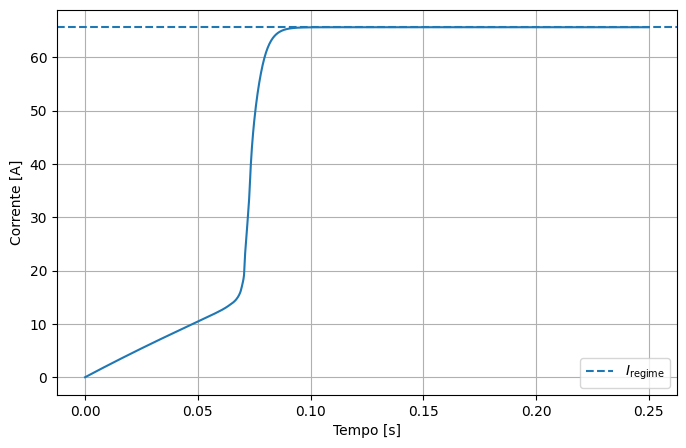

In [ ]:
# Passo temporal pequeno para representar adequadamente o transitório
n_pontos = 1001
t = np.linspace(0, 0.25, n_pontos)
dt = t[1] - t[0]

R_eq = Rb
I_regime = V / R_eq

def determina_Ik(I_km1, theta=0, tolerancia=1e-7):
    """
    Um passo do método de Euler implícito aplicado a:

        V = R*i + d(lambda)/dt

    A corrente I_k é obtida por bisseção.
    """
    fluxo_Ikm1 = fluxo_concatenado(I_km1, theta)

    def equacao_discreta(I_k):
        return (
            fluxo_concatenado(I_k, theta)
            - fluxo_Ikm1
            + R_eq*I_k*dt
            - V*dt
        )

    a = I_km1
    b = I_regime

    fa = equacao_discreta(a)
    fb = equacao_discreta(b)

    if abs(fa) < 1e-14:
        return a

    if fa*fb > 0:
        raise ValueError(
            "O intervalo escolhido não contém uma raiz: "
            f"f(a)={fa:.4e}, f(b)={fb:.4e}"
        )

    while abs(b-a) > tolerancia:
        c = 0.5*(a+b)
        fc = equacao_discreta(c)

        if fa*fc <= 0:
            b = c
        else:
            a = c
            fa = fc

    return 0.5*(a+b)

I_array = np.zeros_like(t)

for k in range(1, len(t)):
    I_array[k] = determina_Ik(I_array[k-1], theta=0)

plt.figure(figsize=(8, 5))
plt.plot(t, I_array)
plt.axhline(I_regime, linestyle='--', label=r'$I_{\mathrm{regime}}$')
plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()


I_regime = 65.6394 A
0.95*I_regime = 62.3574 A
Tempo para atingir 95% = 0.081577 s
Tempo para atingir 95% = 81.577 ms


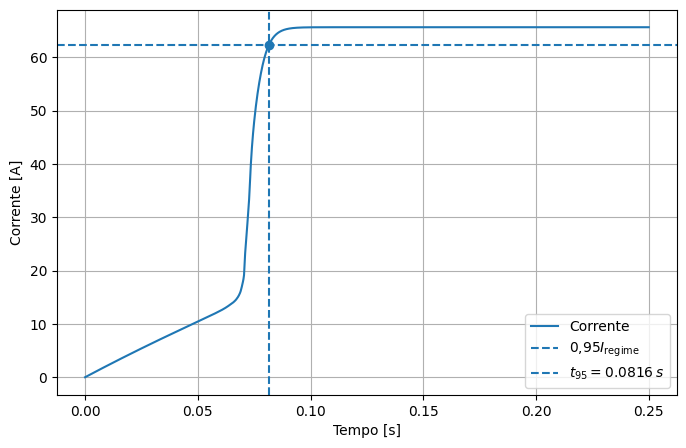

In [ ]:
I_95 = 0.95*I_regime

indices = np.where(I_array >= I_95)[0]

if len(indices) == 0:
    raise RuntimeError(
        "A corrente não atingiu 95% no intervalo simulado."
    )

k_95 = indices[0]

if k_95 == 0:
    t_95 = t[0]
else:
    # Interpolação linear entre os dois pontos que cercam I_95
    t1, t2 = t[k_95 - 1], t[k_95]
    I1, I2 = I_array[k_95 - 1], I_array[k_95]

    t_95 = t1 + (I_95 - I1)*(t2 - t1)/(I2 - I1)

print(f"I_regime = {I_regime:.4f} A")
print(f"0.95*I_regime = {I_95:.4f} A")
print(f"Tempo para atingir 95% = {t_95:.6f} s")
print(f"Tempo para atingir 95% = {1e3*t_95:.3f} ms")

plt.figure(figsize=(8, 5))
plt.plot(t, I_array, label='Corrente')
plt.axhline(I_95, linestyle='--', label=r'$0{,}95I_{\mathrm{regime}}$')
plt.axvline(t_95, linestyle='--', label=fr'$t_{{95}}={t_95:.4f}\,s$')
plt.scatter([t_95], [I_95])
plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()


### Questão 5 ###

Posição do rotor: 59.0°
Corrente inicial: 65.6394 A
Corrente segura: 3.2820 A
Tempo limite: 0.027192 s
Tempo com tensão externa nula: 0.014896 s
Magnitude reversa mínima: 0.000000 V
Conclusão: nenhuma tensão reversa é necessária para cumprir o limite temporal. Qualquer tensão reversa positiva reduzirá ainda mais o tempo.


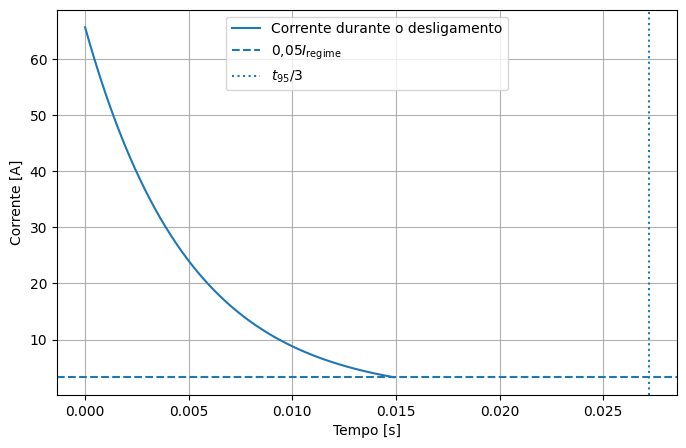

In [ ]:
# ============================================================
# QUESTÃO 5
# ============================================================

theta_desligamento = 59.0
R_eq = Rb

I_inicial = I_regime
I_segura = 0.05*I_regime
tempo_limite = t_95/3

# Grade crescente de corrente para a integração em d(lambda)
n_pontos_fluxo = 5001
correntes_q5 = np.linspace(I_segura, I_inicial, n_pontos_fluxo)

fluxos_q5 = np.array([
    fluxo_concatenado(i, theta_desligamento)
    for i in correntes_q5
])

delta_fluxo = np.diff(fluxos_q5)
corrente_media = 0.5*(correntes_q5[:-1] + correntes_q5[1:])

if np.any(delta_fluxo < -1e-12):
    raise ValueError(
        "A curva lambda(i) não é monotonicamente crescente."
    )

def calcula_tempo_desligamento(V_rev):
    """
    V_rev é a magnitude positiva da tensão reversa.
    A tensão aplicada fisicamente é -V_rev.
    """
    if V_rev < 0:
        raise ValueError("V_rev deve ser maior ou igual a zero.")

    denominador = V_rev + R_eq*corrente_media

    if np.any(denominador <= 0):
        raise ValueError("O denominador deve permanecer positivo.")

    # Integral: t = integral d(lambda)/(V_rev + R*i)
    return np.sum(delta_fluxo/denominador)

def curva_desligamento(V_rev):
    """
    Retorna t e i desde I_inicial até I_segura.
    """
    i_desc = correntes_q5[::-1]
    lambda_desc = fluxos_q5[::-1]

    delta_lambda_desc = lambda_desc[:-1] - lambda_desc[1:]
    i_media_desc = 0.5*(i_desc[:-1] + i_desc[1:])

    dt_desc = delta_lambda_desc/(V_rev + R_eq*i_media_desc)
    tempo_desc = np.concatenate(([0.0], np.cumsum(dt_desc)))

    return tempo_desc, i_desc

tempo_sem_reversao = calcula_tempo_desligamento(0.0)

if tempo_sem_reversao <= tempo_limite:
    # O decaimento natural em circuito de tensão nula já satisfaz a condição.
    V_rev_minima = 0.0
    atende_sem_reversao = True
else:
    atende_sem_reversao = False

    def objetivo(V_rev):
        return calcula_tempo_desligamento(V_rev) - tempo_limite

    V_superior = max(V, 1.0)

    while objetivo(V_superior) > 0:
        V_superior *= 2.0

    V_rev_minima = brentq(
        objetivo,
        0.0,
        V_superior,
        xtol=1e-12,
        rtol=1e-12
    )

# Quando V_rev_minima > 0, aplica-se margem de 1%.
# Se o mínimo é zero, não existe menor valor estritamente positivo:
# qualquer V_rev > 0 torna o desligamento ainda mais rápido.
V_rev_adotada = 1.01*V_rev_minima if V_rev_minima > 0 else 0.0
tempo_obtido = calcula_tempo_desligamento(V_rev_adotada)

print(f"Posição do rotor: {theta_desligamento:.1f}°")
print(f"Corrente inicial: {I_inicial:.4f} A")
print(f"Corrente segura: {I_segura:.4f} A")
print(f"Tempo limite: {tempo_limite:.6f} s")
print(f"Tempo com tensão externa nula: {tempo_sem_reversao:.6f} s")
print(f"Magnitude reversa mínima: {V_rev_minima:.6f} V")

if atende_sem_reversao:
    print(
        "Conclusão: nenhuma tensão reversa é necessária para cumprir "
        "o limite temporal. Qualquer tensão reversa positiva reduzirá "
        "ainda mais o tempo."
    )
else:
    print(f"Magnitude reversa adotada: {V_rev_adotada:.6f} V")
    print(f"Tensão aplicada à bobina: {-V_rev_adotada:.6f} V")
    print(f"Tempo obtido: {tempo_obtido:.6f} s")

tempo_curva, corrente_curva = curva_desligamento(V_rev_adotada)

plt.figure(figsize=(8, 5))
plt.plot(tempo_curva, corrente_curva, label='Corrente durante o desligamento')
plt.axhline(
    I_segura,
    linestyle='--',
    label=r'$0{,}05I_{\mathrm{regime}}$'
)
plt.axvline(
    tempo_limite,
    linestyle=':',
    label=r'$t_{95}/3$'
)
plt.xlabel('Tempo [s]')
plt.ylabel('Corrente [A]')
plt.grid(True)
plt.legend()
plt.show()
